# Problem Statement
**The goal of this project is to build a machine learning model that predicts whether a borrower will repay a loan or default based on financial, demographic, and credit-related features.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset 

In [2]:
df = pd.read_csv('loan_dataset.csv')

In [3]:
df

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,39,Female,Married,Bachelor's,39640.08,3303.34,Employed,0.275,691,16322.23,...,36,566.22,C5,2,23748.10,5801.45,1,0,4,0
19996,66,Female,Married,Bachelor's,32062.90,2671.91,Employed,0.367,758,16697.34,...,36,553.71,B5,8,49929.65,40901.31,3,0,3,1
19997,65,Female,Single,Master's,18642.02,1553.50,Student,0.106,751,23924.78,...,36,772.66,B4,3,13137.57,5075.67,1,0,2,1
19998,35,Male,Married,Master's,22181.39,1848.45,Retired,0.275,646,16920.13,...,36,595.36,D2,5,19580.82,3876.16,4,0,5,1


# EDA Process

In [4]:
df.shape

(20000, 22)

In [5]:
df.dtypes

age                       int64
gender                   object
marital_status           object
education_level          object
annual_income           float64
monthly_income          float64
employment_status        object
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
loan_purpose             object
interest_rate           float64
loan_term                 int64
installment             float64
grade_subgrade           object
num_of_open_accounts      int64
total_credit_limit      float64
current_balance         float64
delinquency_history       int64
public_records            int64
num_of_delinquencies      int64
loan_paid_back            int64
dtype: object

In [6]:
df.isnull().sum()

age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

In [8]:
df.describe()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637766,3629.136466,0.177019,679.25695,15129.300909,12.400626,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


**Target columns**

In [10]:
df['loan_paid_back'].isnull().sum()

np.int64(0)

In [11]:
df['loan_paid_back'].value_counts()

loan_paid_back
1    15998
0     4002
Name: count, dtype: int64

Here classes are imbalanced , Using SMOTE() to balance the classes.

In [12]:
df.drop_duplicates(inplace=True)

# Visualization

(array([ 4002.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 15998.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

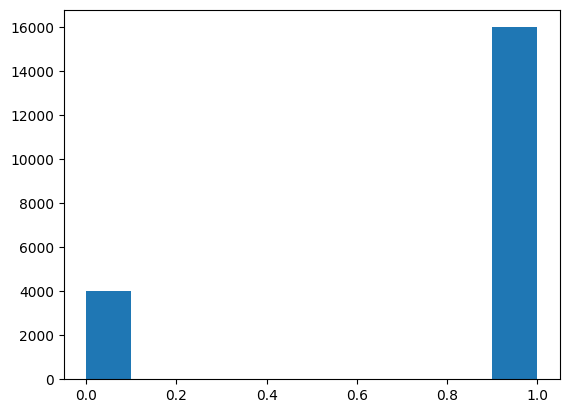

In [13]:
plt.hist(df['loan_paid_back'])

<Axes: xlabel='annual_income', ylabel='loan_amount'>

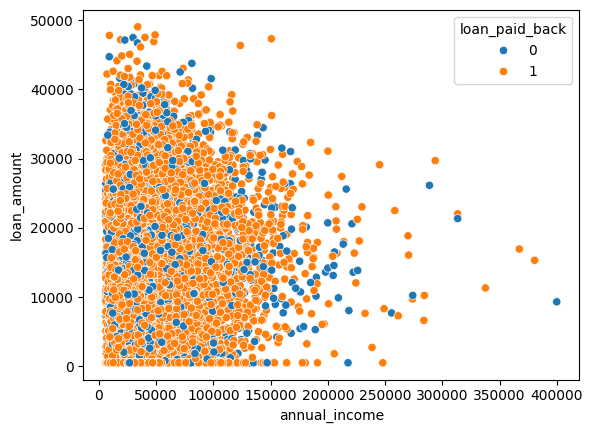

In [14]:
sns.scatterplot(data=df , x = "annual_income" , y = "loan_amount" , hue="loan_paid_back")

<Axes: xlabel='credit_score', ylabel='annual_income'>

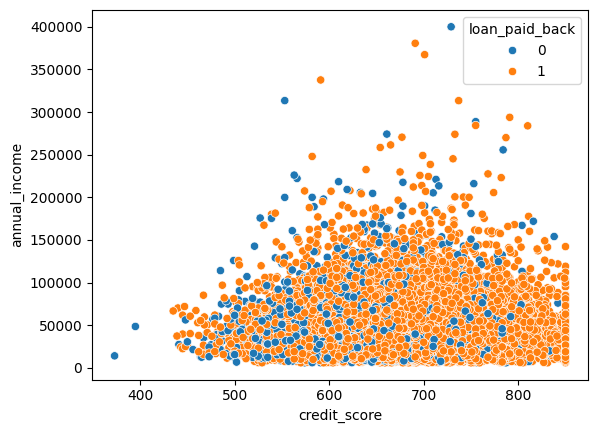

In [15]:
sns.scatterplot(data=df , x= "credit_score" , y= "annual_income" , hue="loan_paid_back")

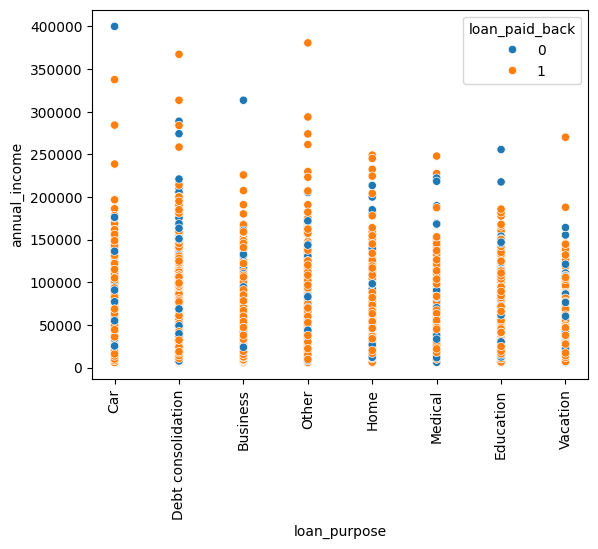

In [16]:
sns.scatterplot(data=df , x= "loan_purpose" , y= "annual_income" , hue="loan_paid_back")
plt.xticks(rotation = 90)
plt.show()

<Axes: xlabel='employment_status', ylabel='count'>

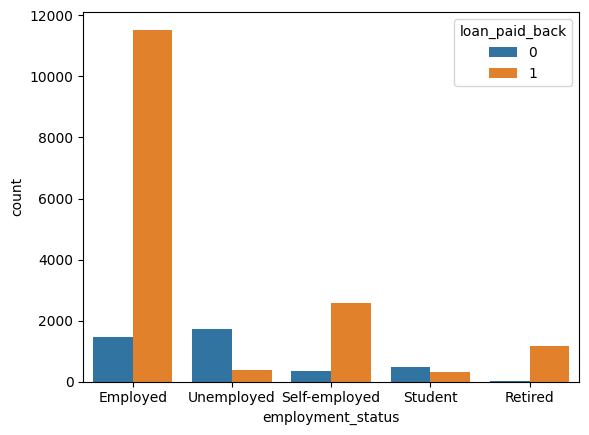

In [17]:
# Employment_status vs loan_paid_back
sns.countplot(data=df , x="employment_status",hue="loan_paid_back")

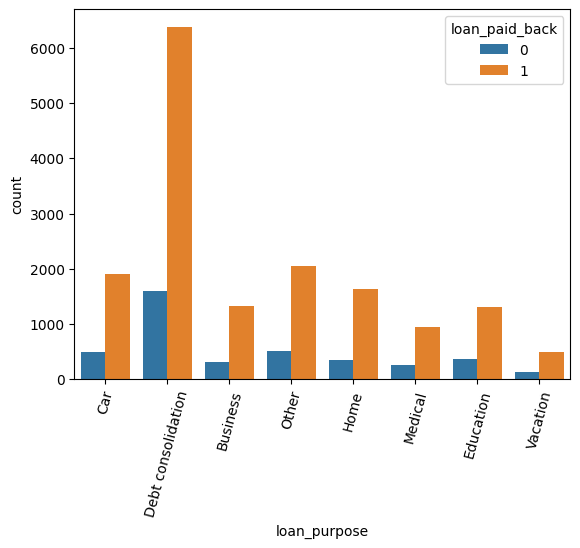

In [18]:
# Loan_purpose vs loan_paid_back
sns.countplot(data=df , x="loan_purpose",hue="loan_paid_back")
plt.xticks(rotation=75)
plt.show()

<Axes: xlabel='marital_status', ylabel='count'>

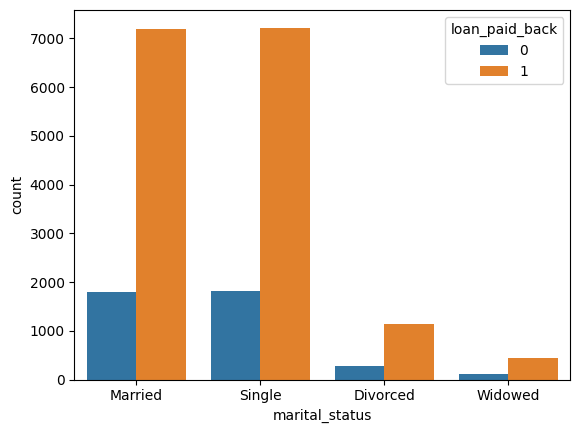

In [19]:
# Marital_status vs loan_paid_back
sns.countplot(data = df , x="marital_status",hue="loan_paid_back")

<Axes: xlabel='education_level', ylabel='count'>

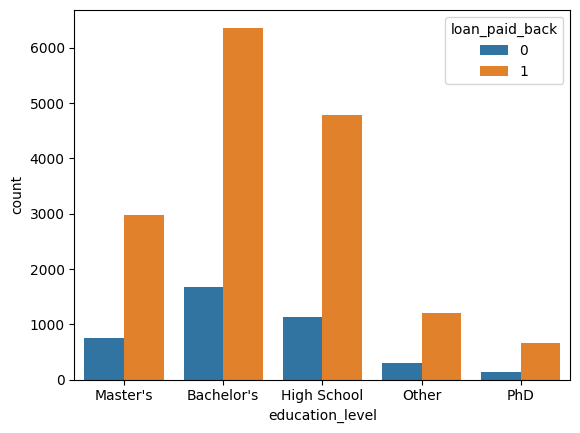

In [20]:
sns.countplot(data=df , x="education_level", hue="loan_paid_back")

<Axes: xlabel='delinquency_history', ylabel='num_of_delinquencies'>

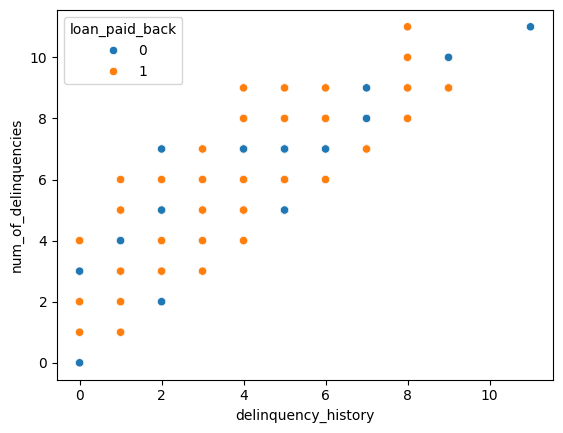

In [21]:
sns.scatterplot(data=df,x="delinquency_history", y="num_of_delinquencies",hue="loan_paid_back")

<Axes: xlabel='delinquency_history', ylabel='count'>

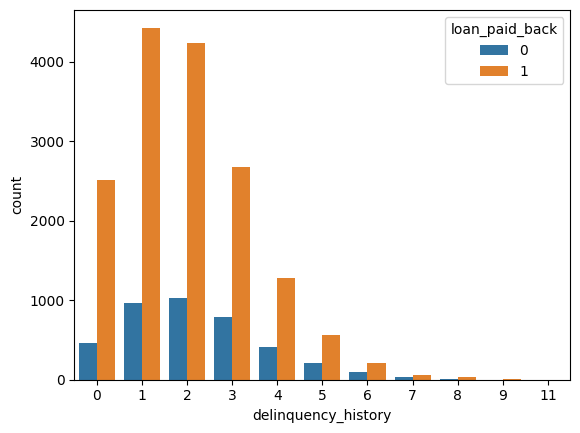

In [22]:
# Delinquency_history  vs  loan_paid_back
sns.countplot(data=df ,x="delinquency_history",hue="loan_paid_back")

<Axes: xlabel='public_records', ylabel='count'>

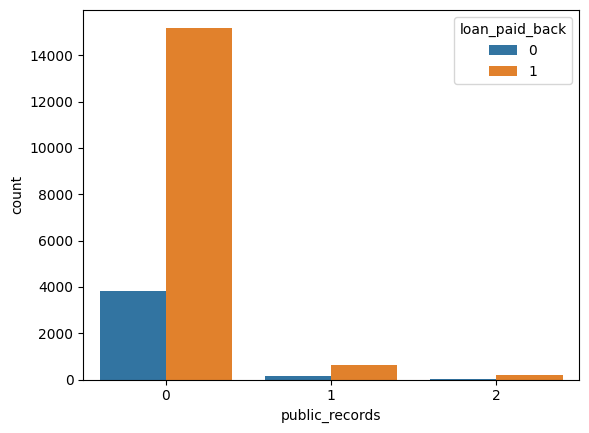

In [23]:
# Public records vs loan_paid_back
sns.countplot(data=df ,x="public_records",hue="loan_paid_back")

# train_test_split the data

**Define "X" as features and "y" as target.**

In [24]:
X = df.drop('loan_paid_back', axis=1)
y = df['loan_paid_back']

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
X_train.shape , X_test.shape

((16000, 21), (4000, 21))

# Preprocessing the Data

In [28]:
# Separate the categorical values and Numerical values.
categorical = X.select_dtypes(include=["object"]).columns
numerical = X.select_dtypes(include=["int64","float64"]).columns

In [29]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [30]:
preprocess_data = ColumnTransformer(
    transformers=[
        ("cat" , OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", StandardScaler() , numerical)
    ]
)

In [31]:
X_train_process = preprocess_data.fit_transform(X_train)
X_test_process  = preprocess_data.transform(X_test)

In [32]:
X_train_process

array([[ 1.        ,  0.        ,  0.        , ..., -1.357122  ,
        -0.21698922, -1.53547394],
       [ 0.        ,  1.        ,  0.        , ..., -1.357122  ,
        -0.21698922, -1.53547394],
       [ 1.        ,  0.        ,  0.        , ..., -0.67660451,
        -0.21698922,  0.30889305],
       ...,
       [ 1.        ,  0.        ,  0.        , ..., -0.67660451,
        -0.21698922, -0.30589595],
       [ 1.        ,  0.        ,  0.        , ...,  0.68443046,
        -0.21698922,  0.30889305],
       [ 0.        ,  1.        ,  0.        , ...,  2.04546544,
        -0.21698922,  1.53847104]], shape=(16000, 70))

# Balance the "Loan_paid_back"(Target column) using SMOTE()

In [33]:
from imblearn.over_sampling import SMOTE

In [34]:
smote = SMOTE()

In [35]:
X_train_balanced , y_train_balanced = smote.fit_resample(X_train_process,y_train)

In [36]:
y_train_balanced.value_counts()

loan_paid_back
1    12816
0    12816
Name: count, dtype: int64

Both classes are balanced.

# Apply Model

**1. Logistic Regression (Baseline model)**

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
log_model = LogisticRegression()

In [39]:
log_model.fit(X_train_balanced,y_train_balanced)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [40]:
y_pred_log = log_model.predict(X_test_process)

In [41]:
y_pred_log

array([1, 1, 1, ..., 1, 1, 0], shape=(4000,))

**Evaluate the Logistic model**

In [42]:
from sklearn.metrics import confusion_matrix,accuracy_score , classification_report

In [43]:
# Cheaking Accuracy
accuracy = accuracy_score(y_test,y_pred_log)
print("Accuracy", accuracy)

Accuracy 0.816


In [44]:
# Confusion matrix
conf_max_log = confusion_matrix(y_test,y_pred_log)
print("Confusion Matrix :")
print(conf_max_log)

Confusion Matrix :
[[ 585  233]
 [ 503 2679]]


In [45]:
# Classification Report 
class_repo_log = classification_report(y_test,y_pred_log)
print("Classification Report :")
print(class_repo_log)

Classification Report :
              precision    recall  f1-score   support

           0       0.54      0.72      0.61       818
           1       0.92      0.84      0.88      3182

    accuracy                           0.82      4000
   macro avg       0.73      0.78      0.75      4000
weighted avg       0.84      0.82      0.82      4000



**Cheaking Overfitting Logistic model**

In [46]:
train_pred_log = log_model.predict(X_train_balanced)
train_acc_log = accuracy_score(y_train_balanced,train_pred_log)

test_pred_log = log_model.predict(X_test_process)
test_acc_log = accuracy_score(y_test,test_pred_log)

In [47]:
print("Traning Accuracy :" , train_acc_log)
print("Testing Accuracy :", test_acc_log)

Traning Accuracy : 0.8067649812734082
Testing Accuracy : 0.816


**2. Random Forest Classifier**

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
rfc_model = RandomForestClassifier(n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42)

In [50]:
rfc_model.fit(X_train_balanced,y_train_balanced)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [51]:
y_pred_rfc = rfc_model.predict(X_test_process)

In [52]:
y_pred_rfc

array([1, 1, 1, ..., 1, 1, 0], shape=(4000,))

**Evaluate the RandomForestClassifier model**

In [53]:
# Cheaking accuracy
acc_rfc = accuracy_score(y_test,y_pred_rfc)
print("Accuracy score :",acc_rfc)

Accuracy score : 0.88525


In [54]:
# Confusion Matrix
conf_max_rfc = confusion_matrix(y_test,y_pred_rfc)
print("Confusion Matrix :")
print(conf_max_rfc)

Confusion Matrix :
[[ 434  384]
 [  75 3107]]


In [55]:
# Classification Report 
class_repo_rfc = classification_report(y_test,y_pred_rfc)
print("Classification Report :")
print(class_repo_rfc)

Classification Report :
              precision    recall  f1-score   support

           0       0.85      0.53      0.65       818
           1       0.89      0.98      0.93      3182

    accuracy                           0.89      4000
   macro avg       0.87      0.75      0.79      4000
weighted avg       0.88      0.89      0.87      4000



**Cheaking Overfitting (Random Forest Classifier model)**

In [56]:
train_pred_rfc = rfc_model.predict(X_train_balanced)
train_acc_rfc = accuracy_score(y_train_balanced,train_pred_rfc)

test_pred_rfc = rfc_model.predict(X_test_process)
test_acc_rfc = accuracy_score(y_test,test_pred_rfc)

In [57]:
print("Traning Accuracy :" ,train_acc_rfc)
print("Testing Accuracy :", test_acc_rfc)

Traning Accuracy : 0.9125702247191011
Testing Accuracy : 0.88525


**No Overfitting founded , the gaps between "Traning accuracy" and "Testing accuracy" is "3%" which is good model.**

# Final Pipeline

In [58]:
from imblearn.pipeline import Pipeline

In [59]:
model_pipeline = Pipeline([
    ("preprocess",preprocess_data),
    ("smote",smote),
    ("model",rfc_model)
])

In [60]:
model_pipeline.fit(X_train,y_train)

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The g

# Save the model

In [61]:
import joblib

In [62]:
joblib.dump(model_pipeline,"loan_approval_model.pkl")

['loan_approval_model.pkl']

# Deployment (Streamlit app)

In [64]:
import streamlit as st
import joblib
import pandas as pd

model = joblib.load("loan_approval_model.pkl")

st.title("Loan Approval Prediction")

st.write("Enter Borrower details")

# Inputs
age = st.number_input("Age")

gender = st.selectbox("Gender", ["Male", "Female","Other"])

marital_status = st.selectbox("Marital Status", ["Single", "Married","Divorced" ,"Widowed"])

education_level = st.selectbox("Education", ["Bachelor's", "High School" ,"Master's","PhD","Other"])

annual_income = st.number_input("Annual Income")

monthly_income = st.number_input("Monthly Income")

employment_status = st.selectbox("Employment", ["Employed", "Unemployed" ,"Self-employed","Student","Retired"])

debt_to_income_ratio = st.number_input("Debt to Income Ratio")

credit_score = st.number_input("Credit Score")

loan_amount = st.number_input("Loan Amount")

loan_purpose = st.selectbox("Loan Purpose", ["Car", "Home", "Education","Business","Medical","Vacation","Debt consolidation","Other"])

interest_rate = st.number_input("Interest Rate")

loan_term = st.number_input("Loan Term")

installment = st.number_input("Installment")

grade_subgrade = st.selectbox("Grade", ["A1","A2","A3","B1","B2","B3","C1","C2","C3","D1","D2","D3","E1","E2","E3"])

num_of_open_accounts = st.number_input("Open Accounts")

total_credit_limit = st.number_input("Total Credit Limit")

current_balance = st.number_input("Current Balance")

delinquency_history = st.number_input("Delinquency History")

public_records = st.number_input("Public Records")

num_of_delinquencies = st.number_input("Number of Delinquencies")

if st.button("Predict"):
    data = pd.DataFrame({
        "age":[age],
        "gender":[gender],
        "marital_status":[marital_status],
        "education_level":[education_level],
        "annual_income":[annual_income],
        "monthly_income":[monthly_income],
        "employment_status":[employment_status],
        "debt_to_income_ratio":[debt_to_income_ratio],
        "credit_score":[credit_score],
        "loan_amount":[loan_amount],
        "loan_purpose":[loan_purpose],
        "interest_rate":[interest_rate],
        "loan_term":[loan_term],
        "installment":[installment],
        "grade_subgrade":[grade_subgrade],
        "num_of_open_accounts":[num_of_open_accounts],
        "total_credit_limit":[total_credit_limit],
        "current_balance":[current_balance],
        "delinquency_history":[delinquency_history],
        "public_records":[public_records],
        "num_of_delinquencies":[num_of_delinquencies]
    })

    result = model.predict(data)

    if result[0] == 1:
        st.success("Loan Will be Paid Back")
    else:
        st.error("Loan Risk")

2026-04-01 07:06:09.550 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 07:06:09.558 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 07:06:09.571 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 07:06:09.583 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 07:06:09.587 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 07:06:09.593 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 07:06:09.607 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 07:06:09.619 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar